In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset from source: https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html
data = load_iris()
X, y = data.data, data.target

# Train-Test-Split data (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

results = {}

In [15]:
tree_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for name, model in tree_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-score": f1_score(y_test, y_pred, average='weighted')
    }

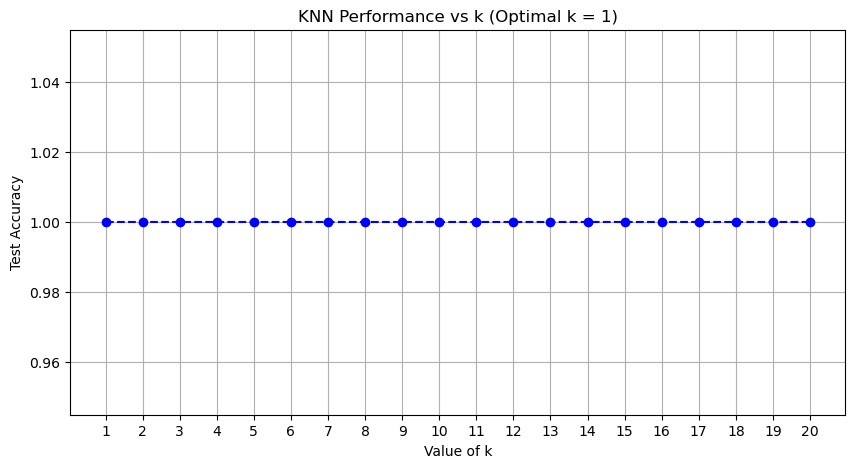

                   Accuracy  Precision  Recall  F1-score
Decision Tree           1.0        1.0     1.0       1.0
Random Forest           1.0        1.0     1.0       1.0
Gradient Boosting       1.0        1.0     1.0       1.0
KNN (k=1)               1.0        1.0     1.0       1.0


In [18]:
k_values = range(1, 21)
k_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    k_scores.append(knn.score(X_test, y_test))

# Identify the optimal k
optimal_k = k_values[k_scores.index(max(k_scores))]

plt.figure(figsize=(10, 5))
plt.plot(k_values, k_scores, marker='o', linestyle='--', color='b')
plt.title(f'KNN Performance vs k (Optimal k = {optimal_k})')
plt.xlabel('Value of k')
plt.ylabel('Test Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# KNN training with optimal k
best_knn = KNeighborsClassifier(n_neighbors=optimal_k)
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)

results[f"KNN (k={optimal_k})"] = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn, average='weighted'),
    "Recall": recall_score(y_test, y_pred_knn, average='weighted'),
    "F1-score": f1_score(y_test, y_pred_knn, average='weighted')
}

# Create summary table
df_results = pd.DataFrame(results).T
print(df_results)

# Result evaluation
## Dataset Balance

The Iris dataset is perfectly balanced, containing **50 samples per class**.  
When class distributions are balanced, the **weighted averages** of Precision and Recall mathematically converge toward the **Accuracy** score.

In contrast, for an imbalanced dataset (e.g., 90% Class A and 10% Class B), these metrics would begin to diverge, as misclassifications in the minority class would have a stronger impact on Precision and Recall.

---

## Small Test Size

Using a **30% test split** results in only **45 test samples**.  
For a dataset as simple and well-structured as Iris, it is statistically very likely that models such as **Random Forest** or **K-Nearest Neighbors (KNN)** classify all samples correctly.

When there are **zero misclassifications** (i.e., FP = 0 and FN = 0), the evaluation metrics resolve as follows:

$\text{Precision} = \text{Recall} = \text{F1-score} = 1.0$


---

## Model Comparison: Why did all models perform well?

### Tree-Based Models

Decision Trees operate by learning a sequence of **if–then rules** (e.g., *Is petal length > 2.45?*).  
Because Iris species occupy clearly separated feature ranges, tree-based models can identify near-perfect decision boundaries with very few splits.

### K-Nearest Neighbors (KNN)

Flowers of the same species tend to cluster tightly in feature space.  
KNN classifies a sample based on the labels of its nearest neighbors. Due to the strong separation between species clusters, a flower’s neighbors almost always belong to the same class, leading to highly accurate predictions.
